In [1]:
import numpy as np
import matplotlib.pyplot as plt

from helpers.geometry_map import make_geometry_map, build_dist_tree_from_map
from helpers.data_transforms import load_in_data

from tqdm import tqdm
from helpers.material_map import apply_material_map_hybrid, build_masked_datasets
from helpers.flow import build_z_lookup, snap_z_to_detector


In [ ]:
geo_map_path = "/pscratch/sd/r/rmastand/muon_collider/geometry_map.txt"

# make_geometry_map(
#     df,
#     collections,
#     geo_map_path,
#     num_events_per_col=1_000_000,
    
# )

In [ ]:
tree_map, cellid_layer_map = build_dist_tree_from_map(geo_map_path)

In [ ]:
BIN_BOUND = 5
NUM_BINS = 60
NUM_FEATURES = 5
NUM_BDTS = 10

collections = [
    "InnerTrackerBarrelCollection",
   "InnerTrackerEndcapCollection",
    "OuterTrackerBarrelCollection",     
    "OuterTrackerEndcapCollection",  
   "VertexBarrelCollection",   
  "VertexEndcapCollection",
]


feature_order_endcap = [0,4,1,2,3,6,7,8,9]
feature_indices_dict_endcap = {
    "r":2,
    "phi": 3,
    "z":4,
    "side":5,
    "layer":6,
    "sensor":8
}

feature_order_barrel =[0,4,1,2,3,6,7,8,9]
feature_indices_dict_barrel = {
   "r":2,
    "phi": 3,
    "z":4,
    "side":5,
    "layer":6
}

feature_order_dict = {
     "InnerTrackerBarrelCollection":feature_order_barrel,
    "InnerTrackerEndcapCollection":feature_order_endcap,
    "OuterTrackerBarrelCollection":feature_order_barrel,
    "OuterTrackerEndcapCollection":feature_order_endcap,  
    "VertexBarrelCollection":feature_order_barrel,
    "VertexEndcapCollection":feature_order_endcap,

}


feature_indices_dict = {
     "InnerTrackerBarrelCollection":feature_indices_dict_barrel,
    "InnerTrackerEndcapCollection":feature_indices_dict_endcap,
    "OuterTrackerBarrelCollection":feature_indices_dict_barrel,
    "OuterTrackerEndcapCollection":feature_indices_dict_endcap,  
    "VertexBarrelCollection":feature_indices_dict_barrel,
    "VertexEndcapCollection":feature_indices_dict_endcap,

}



ZUKO_ID = "NCSF"
NAME = "cond4"
NUM_COND_INPUTS = 4
SEED = 8



FEATURES = "rphi"
working_dir = "/pscratch/sd/r/rmastand/muon_collider"
log_vars = []



In [ ]:
# load in samples

all_data_dir, all_samples_dir = {}, {}


for col_name in collections:

    small_id = ''.join([c for c in col_name if c.isupper()])
    X, feature_labels = load_in_data([col_name], FEATURES, working_dir, 1, NUM_COND_INPUTS, feature_order_dict[col_name])
    all_data_dir[col_name] = X
    all_samples_dir[col_name] = np.load(f"{working_dir}/zuko_outputs/{ZUKO_ID}/{small_id}_{NAME}/flow_samples.npy")


    if "Endcap" in col_name:
        plt.figure()
    
        z_idx = feature_indices_dict[col_name]["z"]
        side_idx = feature_indices_dict[col_name]["side"]
        layer_idx = feature_indices_dict[col_name]["layer"]
        sensor_idx = feature_indices_dict[col_name]["sensor"]
    
        # original samples
        z_samples = all_samples_dir[col_name][:, z_idx]
        sides = all_samples_dir[col_name][:, side_idx]
        layers = all_samples_dir[col_name][:, layer_idx]
        sensors = all_samples_dir[col_name][:, sensor_idx]
    
    
        
        z_lookup = build_z_lookup(
            all_data_dir[col_name],
            feature_indices_dict[col_name]["side"],
            feature_indices_dict[col_name]["layer"],
            feature_indices_dict[col_name]["sensor"],
            feature_indices_dict[col_name]["z"],
        )
        # # snap z to detector geometry
        z_samples_snapped = snap_z_to_detector(
            z_samples, sides, layers, sensors, z_lookup
        
        )
        all_samples_dir[col_name][:,feature_indices_dict[col_name]["z"]] = z_samples_snapped
        all_samples_dir[col_name][:,feature_indices_dict[col_name]["side"]] = np.array(sides)
    
        # plot truth vs snapped samples
        plt.hist(
            all_data_dir[col_name][:, z_idx],
            bins=np.linspace(-2000, 2000, 1000),
            histtype="step",
            label="truth"
        )
    
        plt.hist(
            z_samples_snapped,
            bins=np.linspace(-2000, 2000, 1000),
            histtype="step",
            label="flow (snapped)"
        )
    
        plt.yscale("log")
        plt.legend()
        plt.show()
   

In [ ]:



def get_col_hits_per_layer(data):

    

    col_hits_per_layer = {col: {} for col in collections}
    dists  = {col: {} for col in collections}
    cell_ids = {col: {} for col in collections}
    valid_masks = {col: {} for col in collections}

    
    
    for col_name in collections:
    
    
        # -----------------------------
        # 1. Extract coordinates
        # -----------------------------
        r = data[col_name][:,feature_indices_dict[col_name]["r"]]
        phi = data[col_name][:,feature_indices_dict[col_name]["phi"]]
        z = data[col_name][:,feature_indices_dict[col_name]["z"]]
        x = r*np.cos(phi)
        y = r*np.sin(phi)
        
        points = np.stack([x,y,z], axis=1)   # shape (N, 3)
    
        # -----------------------------
        # 2. Mask out NaNs / infs
        # -----------------------------
        valid_mask = np.isfinite(points).all(axis=1)
        points_valid = points[valid_mask]
        valid_masks[col_name] = valid_mask
    
        # Skip if nothing valid
        if len(points_valid) == 0:
            continue
    
        # -----------------------------
        # 3. Batch KDTree query
        # -----------------------------
        dists_batch, idx_batch = tree_map[col_name].query(points_valid)
    
        # -----------------------------
        # 4. Remove invalid KDTree hits
        # -----------------------------
        valid_idx_mask = idx_batch < len(cellid_layer_map[col_name])
    
        idx_batch = idx_batch[valid_idx_mask]
        dists[col_name]  = dists_batch[valid_idx_mask]
    
        # -----------------------------
        # 5. Map to (cell_id, layer)
        # -----------------------------
        cell_layer = cellid_layer_map[col_name][idx_batch]
        layers = cell_layer[:, 1]
        cell_ids[col_name] = cell_layer[:, 0]
    
        # -----------------------------
        # 6. Count hits per layer (vectorized)
        # -----------------------------
        unique_layers, counts = np.unique(layers, return_counts=True)
    
        for layer, count in zip(unique_layers, counts):
            col_hits_per_layer[col_name][layer] = (
                col_hits_per_layer[col_name].get(layer, 0) + count
            )


    return col_hits_per_layer, dists, cell_ids, valid_masks

In [ ]:
col_hits_per_layer_truth, dists_truth, cell_ids_truth, valid_mask = get_col_hits_per_layer(all_data_dir)



In [ ]:



plt.figure()
for i, col in enumerate(collections):
    plt.hist(dists_truth[col], bins = np.linspace(0, 50, 100), histtype = "step", density = True, linestyle = "dashed", color = f"C{i}")
    #plt.hist(dists_samples[col], bins = np.linspace(0, 50, 100), histtype = "step", density = True, color = f"C{i}", label = col)
plt.yscale("log")
plt.xlabel("distance from tree")
plt.ylabel("density")
plt.legend()
plt.show()

In [ ]:
collections_order = [
    'VertexBarrelCollection',
    'VertexEndcapCollection',
    'InnerTrackerBarrelCollection',
    'InnerTrackerEndcapCollection',
    'OuterTrackerBarrelCollection',
    'OuterTrackerEndcapCollection'
]

# Prepare x positions
width = 0.1  # width of each bar
x_offsets = np.arange(0, len(col_hits_per_layer[collections_order[0]]))  # base positions for first collection

fig, ax = plt.subplots(figsize=(12, 6))

# Keep track of total x positions
x_pos = 0
x_labels = []
x_ticks = []

for coll in collections_order:
    layers = sorted(col_hits_per_layer_samples[coll].keys())  # sort layers numerically
    counts = [col_hits_per_layer_samples[coll][l] for l in layers]

    # compute positions for this collection
    positions = x_pos + np.arange(len(layers))
    ax.bar(positions, counts, width=0.8, label=coll)
    
    # collect labels and ticks
    x_labels.extend([f"{l}" for l in layers])
    x_ticks.extend(positions)
    
    # update x_pos for next collection to avoid overlap
    x_pos = positions[-1] + 1  # add gap between collections

ax.set_xticks(x_ticks)
ax.set_xticklabels(x_labels, rotation=45, ha='right')
ax.set_ylabel("Number of hits")
ax.set_title("Hits per Detector Layer")
ax.legend()
plt.tight_layout()
plt.yscale("log")
plt.savefig("figures/hits_per_detector_layer.png")
plt.show()

In [ ]:

_, flow_samples_masked_stratified = build_masked_datasets(all_data_dir, all_samples_dir, collections, NUM_COND_INPUTS, feature_indices_dict)
col_hits_per_layer_samples, dists_samples, cell_ids_samples, valid_masks = get_col_hits_per_layer(flow_samples_masked_stratified)


In [ ]:


for col in collections_order:

    print(col)
    print(flow_samples_masked_stratified[col].shape)
    print(cell_ids_samples[col].shape)


    loc = np.concatenate([flow_samples_masked_stratified[col], cell_ids_samples[col].reshape(-1,1)], axis = 1)


    np.save(f"/pscratch/sd/r/rmastand/muon_collider/npys/flow_samples/{col}.npy", loc)
    print(loc.shape,)

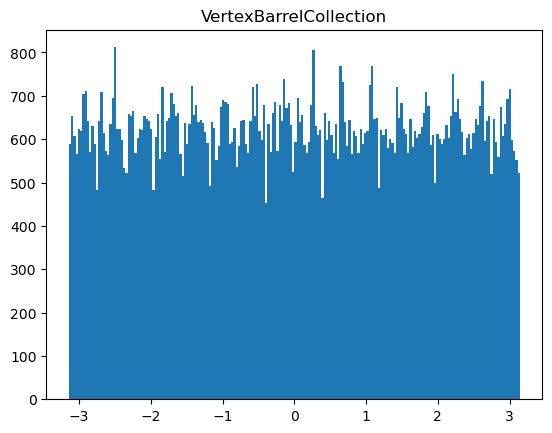

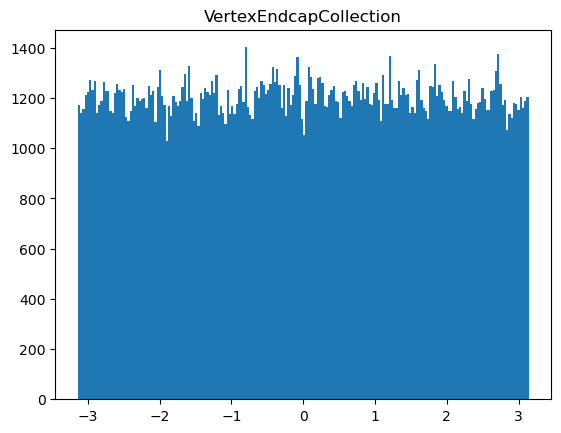

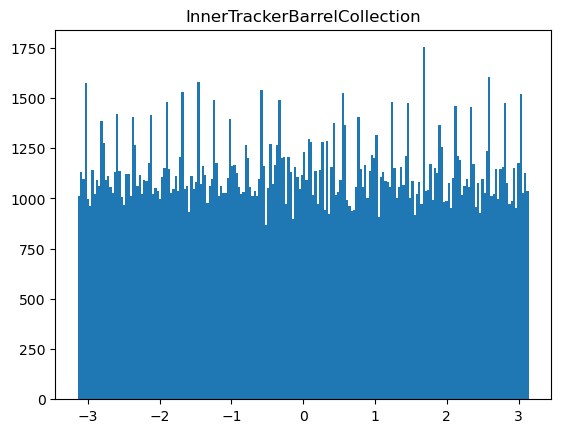

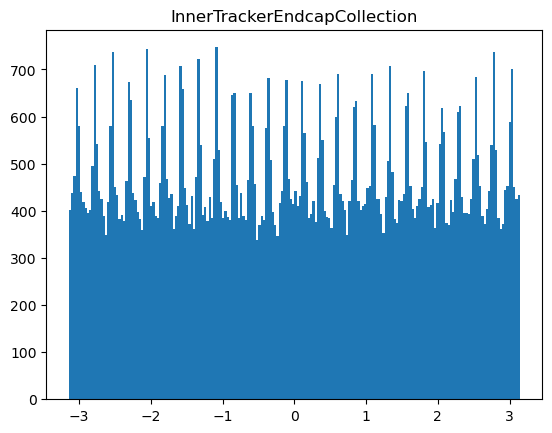

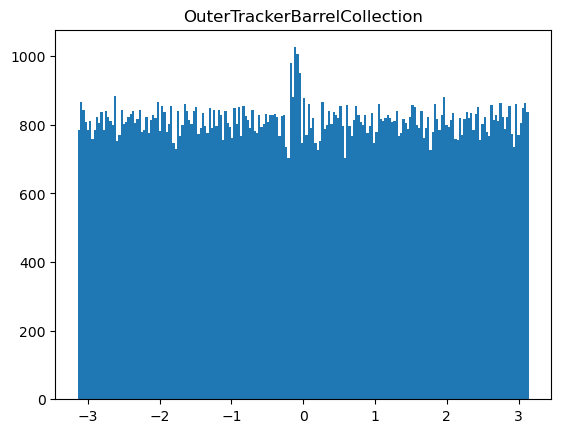

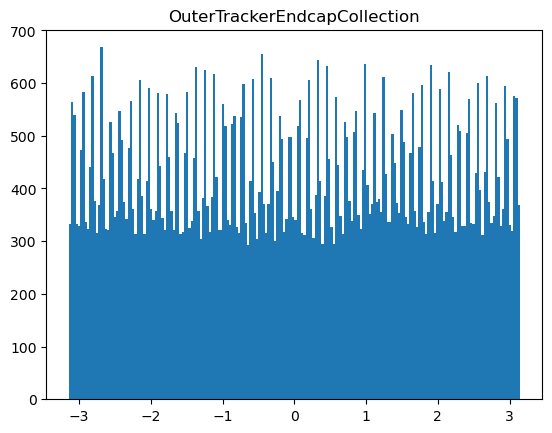

(935396, 10)


In [2]:
data = []

collections_order = [
    'VertexBarrelCollection',
    'VertexEndcapCollection',
    'InnerTrackerBarrelCollection',
    'InnerTrackerEndcapCollection',
    'OuterTrackerBarrelCollection',
    'OuterTrackerEndcapCollection'
]


for col in collections_order:
    tmp = np.load(f"/pscratch/sd/r/rmastand/muon_collider/npys/flow_samples/{col}.npy")
    data.append(tmp)

    plt.figure()
    plt.hist(tmp[:,3], bins = 200)
    plt.title(col)
    plt.show()

data = np.concatenate(data)
print(data.shape)


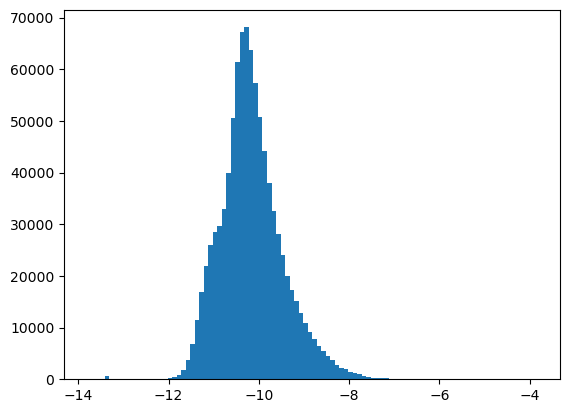

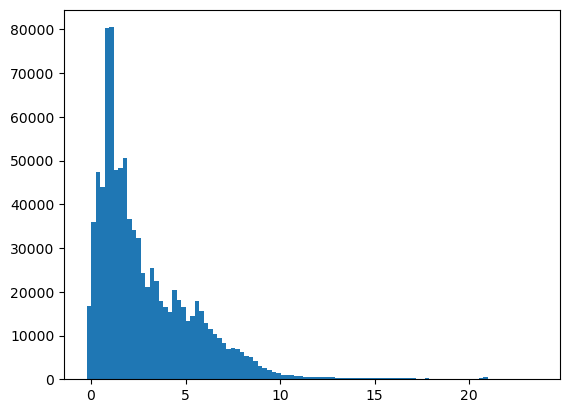

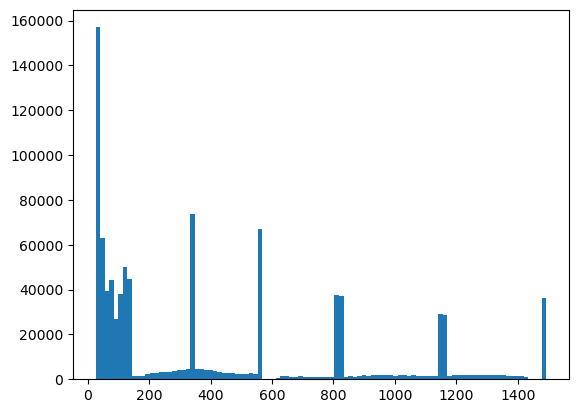

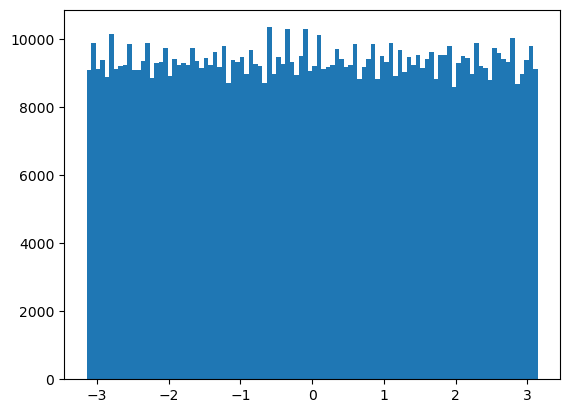

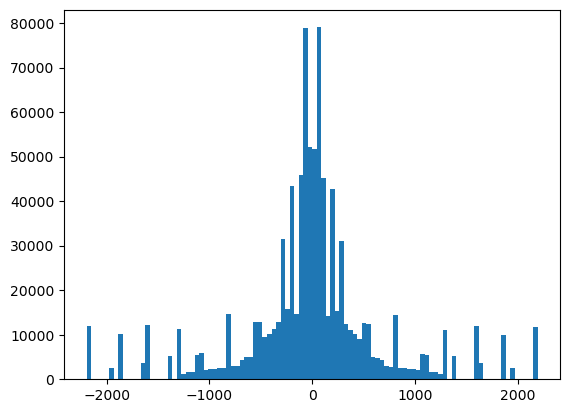

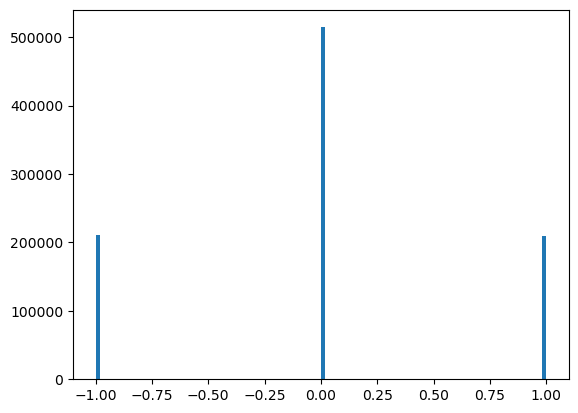

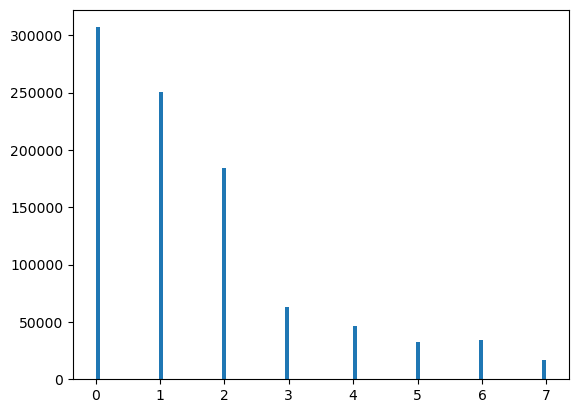

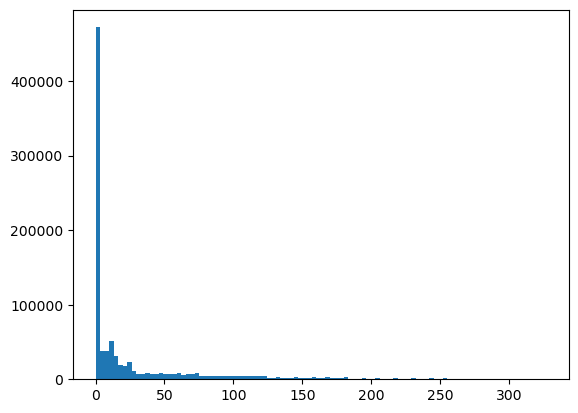

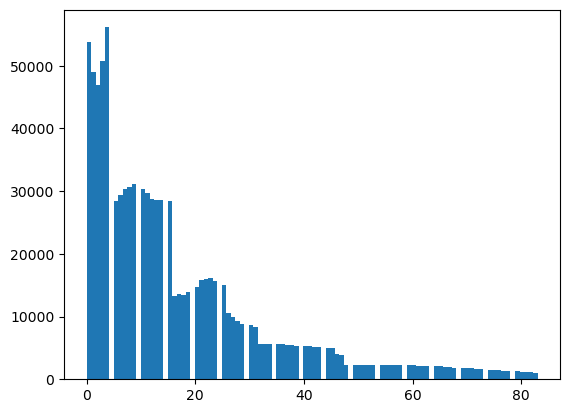

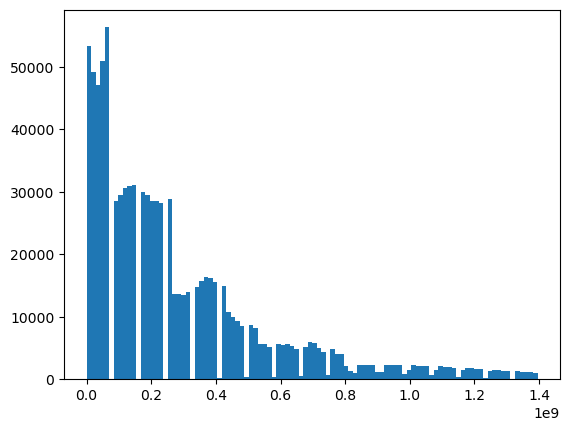

In [3]:
for i in range(data.shape[1]):
    plt.figure()
    plt.hist(data[:,i], bins = 100)
    plt.show()